In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from transformers import pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from collections import Counter
from langdetect import detect
from deep_translator import GoogleTranslator
import time


In [2]:
data_df = pd.read_csv(r'E:\PythonCertificates\Snapchat Sentiment Analysis\archive\snapchat_reviews_translated_copy.csv')
data_df.head(10)

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,cleaned_content,cleaned_content_translated
0,f76179a5-cd22-4f2f-9c37-82f717522624,Priyanshi Yadav,best,3,0,13.86.0.50,2026-04-03 09:45:54,13.86.0.50,best,best
1,4fd959be-8f98-4921-b1b1-00a3f815a632,Oladipupo Oluwasemilore,reputable,5,0,NaN,2026-04-03 09:44:25,NaN,reputable,reputable
2,a30ec738-4603-4c86-a59e-4c13ec1cce54,Angel Buliba,angel 🥰,1,0,12.50.1.0,2026-04-03 09:44:10,12.50.1.0,angel,angel
3,1a01d695-0b0c-4fa2-bcbd-bd7c6da1fcd7,Ranjit Dalai,I think it is the best app,5,0,NaN,2026-04-03 09:41:03,NaN,i think it is the best app,i think it is the best app
4,24b6eab1-8971-4371-be94-b109324116fc,Tejrao More,love how this app work I use from three years ...,4,0,13.79.0.44,2026-04-03 09:38:51,13.79.0.44,love how this app work i use from three years ...,love how this app work i use from three years ...
5,fc8aa553-0ef6-4f6c-90ee-f30bccc25dd9,Indresh Yadav,wow this app was very good,4,0,13.83.0.51,2026-04-03 09:38:08,13.83.0.51,wow this app was very good,wow this app was very good
6,bf698141-1b6a-4060-9404-8750d8b04ae3,Ali Sheikh,very bad,5,0,NaN,2026-04-03 09:35:59,NaN,very bad,very bad
7,7712dde7-8ea0-41b6-8500-33f116003e20,Saqlain Gujjar,💕😘 love,5,0,13.79.0.44,2026-04-03 09:32:30,13.79.0.44,love,love
8,3b222e40-4298-4482-bbc0-dcb6c92b5953,Amitesh Singh,good 👍,5,0,NaN,2026-04-03 09:32:20,NaN,good,good
9,7bc46e9a-8efa-4d19-9a4b-b8e4e9cc370d,Vaseeim__Mewati,vaseeim Khan mewati video kabutar mare gulel s...,4,0,13.85.0.53,2026-04-03 09:32:04,13.85.0.53,vaseeim khan mewati video kabutar mare gulel s...,waseem khan mewati video pigeon kill slingshot...


In [3]:
data_df.describe()

,score,thumbsUpCount
count,199153.000000,199153.000000
mean,3.051573,30.075806
std,1.702438,587.882353
min,1.000000,0.000000
25%,1.000000,0.000000
50%,3.000000,0.000000
75%,5.000000,1.000000
max,5.000000,89130.000000


In [4]:
data_df['content'].describe()

count     199152
unique    199152
top         best
freq           1
Name: content, dtype: object

In [5]:
data_df.duplicated().value_counts()

False    199153
Name: count, dtype: int64

In [6]:
data_df.isnull().sum()

reviewId                          0
userName                          0
content                           1
score                             0
thumbsUpCount                     0
reviewCreatedVersion          46008
at                                0
appVersion                    46008
cleaned_content                   2
cleaned_content_translated        1
dtype: int64

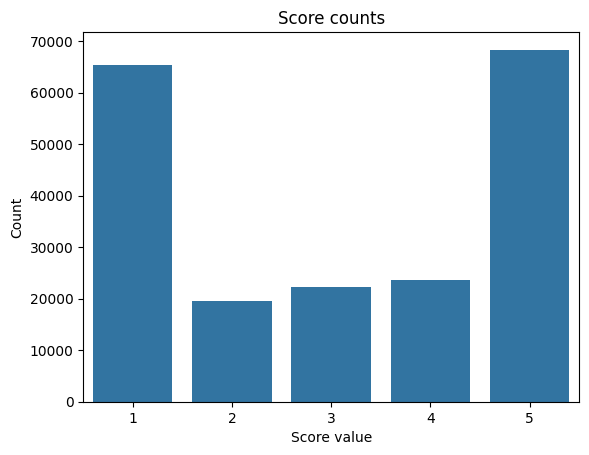

In [7]:
plt.Figure(figsize=(12,6))
sns.countplot(data=data_df, x='score')
plt.xlabel("Score value")
plt.ylabel("Count")
plt.title("Score counts")
plt.show()

In [8]:
data_df = data_df[~data_df['content'].isnull()]
data_df.isnull().sum()

reviewId                          0
userName                          0
content                           0
score                             0
thumbsUpCount                     0
reviewCreatedVersion          46008
at                                0
appVersion                    46008
cleaned_content                   1
cleaned_content_translated        1
dtype: int64

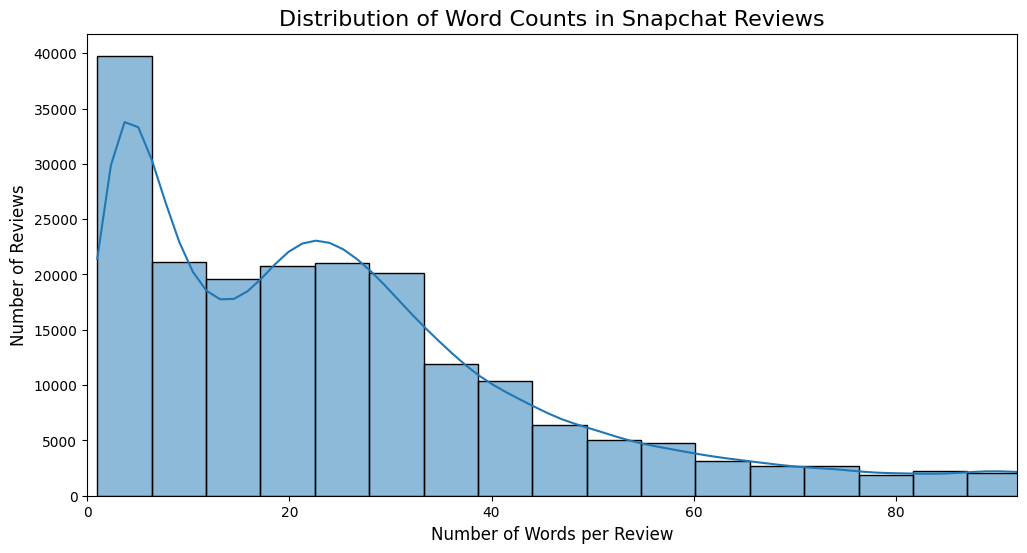

In [9]:
data_df['word_count'] = data_df['content'].astype(str).str.split().str.len()

plt.figure(figsize=(12, 6))
sns.histplot(data_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Counts in Snapchat Reviews', fontsize=16)
plt.xlabel('Number of Words per Review', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xlim(0, data_df['word_count'].quantile(0.98)) 

plt.show()

In [10]:
emoji_pattern = r'[\U00010000-\U0010ffff]'
patterncount = []

def emojifinder(x):
    pattern = re.findall(emoji_pattern, str(x))
    if pattern:
        patterncount.append(pattern)

data_df['content'].apply(emojifinder)

print(f"Total emojis found: {len(patterncount)}")



Total emojis found: 26481


In [11]:
patternbrack = r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)'
patterncount = []

def bracketfinder(x):
    pattern = re.findall(patternbrack, str(x))
    if pattern:
        patterncount.append(pattern)

data_df['content'].apply(bracketfinder)

print(f"Total emojis found: {len(patterncount)}")

Total emojis found: 4107


In [12]:
patternasc11 = r'[^\x00-\x7F]'
patterncount = []

def patternfinder(x):
    pattern = re.findall(patternasc11, str(x))
    if pattern:
        patterncount.append(pattern)

data_df['content'].apply(patternfinder)

print(f"Total emojis found: {len(patterncount)}")

Total emojis found: 30706


In [13]:
httpsurlspattern = r'https?://\S+|www\.\S+'
patterncount = []

def httpsurlfinder(x):
    pattern = re.findall(httpsurlspattern, str(x))
    if pattern:
        patterncount.append(pattern)

data_df['content'].apply(httpsurlfinder)

print(f"Total emojis found: {len(patterncount)}")


Total emojis found: 0


In [14]:
email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
patterncount = []

def emaidfinder(x):
    pattern = re.findall(email_pattern, str(x))
    if pattern:
        patterncount.append(pattern)

data_df['content'].apply(emaidfinder)

print(f"Total emojis found: {len(patterncount)}")

Total emojis found: 0


In [15]:
number_pattern = r'\\d+'

patterncount = []

def numbersfinder(x):
    pattern = re.findall(number_pattern, str(x))
    if pattern:
        patterncount.append(pattern)

data_df['content'].apply(numbersfinder)

print(f"Total emojis found: {len(patterncount)}")


Total emojis found: 0


### Preprocessing

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\x00-\x7F]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', '', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [17]:
data_df['cleaned_text'] = data_df['cleaned_content_translated'].apply(clean_text)
data_df['cleaned_text'].head(10)

0                                                 best
1                                            reputable
2                                                angel
3                                   think the best app
4    love how this app work use from three years th...
5                           wow this app was very good
6                                             very bad
7                                                 love
8                                                 good
9    waseem khan mewati video pigeon kill slingshot...
Name: cleaned_text, dtype: str

In [18]:
data_df = data_df.drop_duplicates(subset=['cleaned_text'])

In [19]:
data_df['cleaned_text'].duplicated().value_counts()

cleaned_text
False    194178
Name: count, dtype: int64

In [20]:
data_df['cleaned_text'].isnull().value_counts()

cleaned_text
False    194178
Name: count, dtype: int64

In [21]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def lda_preprocess(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens if len(word) > 2]
    return " ".join(tokens)

In [22]:
data_df['lda_text'] = data_df['cleaned_text'].apply(lda_preprocess)

In [ ]:
lda_custom_stopwords = {
    'app','snapchat','snap','good','great','nice','amazing','best','love','really','like','get','use',
    'using', 'one','even', 'please', 'time', 'thing', 'good app', 'great app', 'best app', 'love app',
    'nice app', 'really good', 'really good app', 'social medium app', 'social medium platform', 'also',
    'make', 'want', 'take', 'new', 'work', 'problem', 'fix', 'people', 'many', 'see', 'keep', 'back','would',
    'much', 'still'
}

In [24]:
def lda_preprocess_strict(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in lda_custom_stopwords and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [25]:
data_df['lda_text_strict'] = data_df['lda_text'].apply(lda_preprocess_strict)

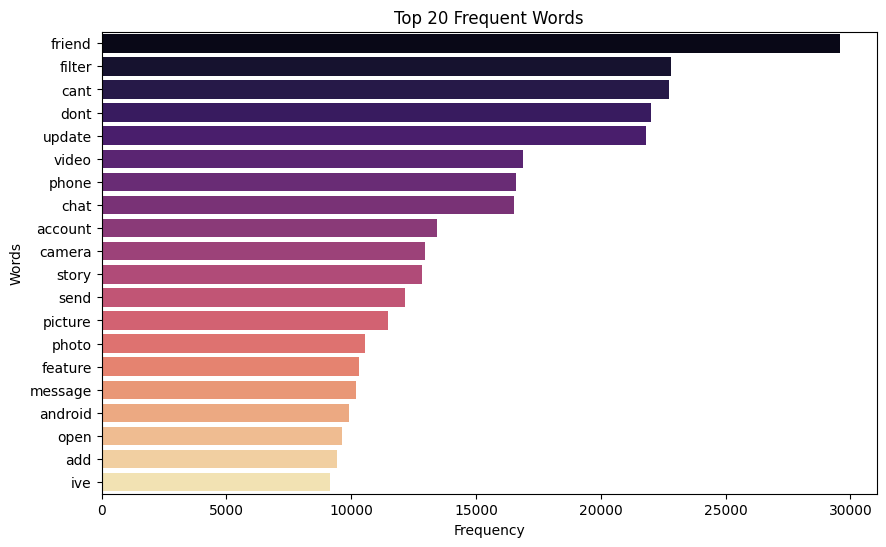

In [26]:
words_aall = [word for text in data_df['lda_text_strict'] for word in str(text).lower().split()]
common_words = Counter(words_aall).most_common(20)
words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, hue=words, palette='magma', legend=False)
plt.title("Top 20 Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

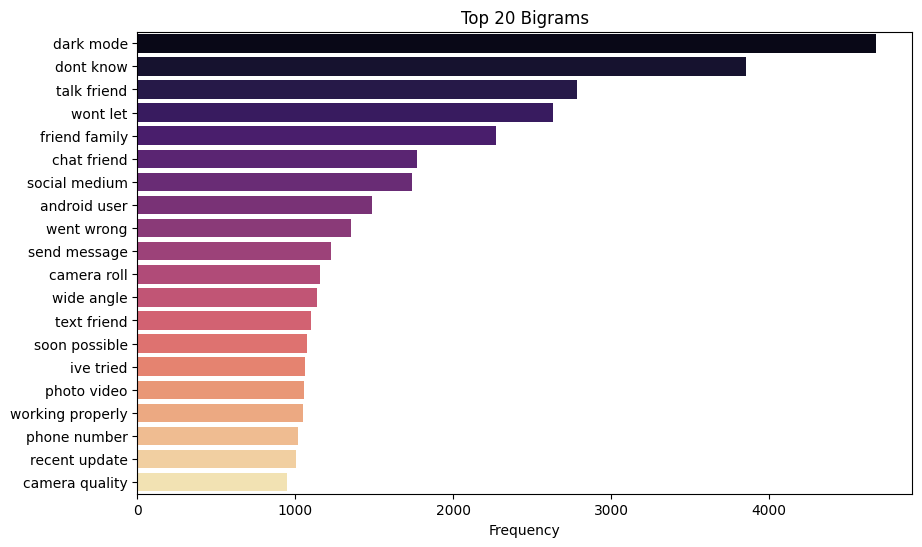

In [27]:
countvec = CountVectorizer(ngram_range=(2,2), stop_words='english')
matrixvec = countvec.fit_transform(data_df['lda_text_strict'])
counts = np.asarray(matrixvec.sum(axis=0)).flatten()
features = countvec.get_feature_names_out()
idx = np.argsort(counts)[::-1][:20]
twords = features[idx]
tcounts = counts[idx]

plt.figure(figsize=(10,6))
sns.barplot(x=tcounts, y=twords, hue=twords, palette='magma', legend=False)
plt.title("Top 20 Bigrams")
plt.xlabel("Frequency")
plt.show()

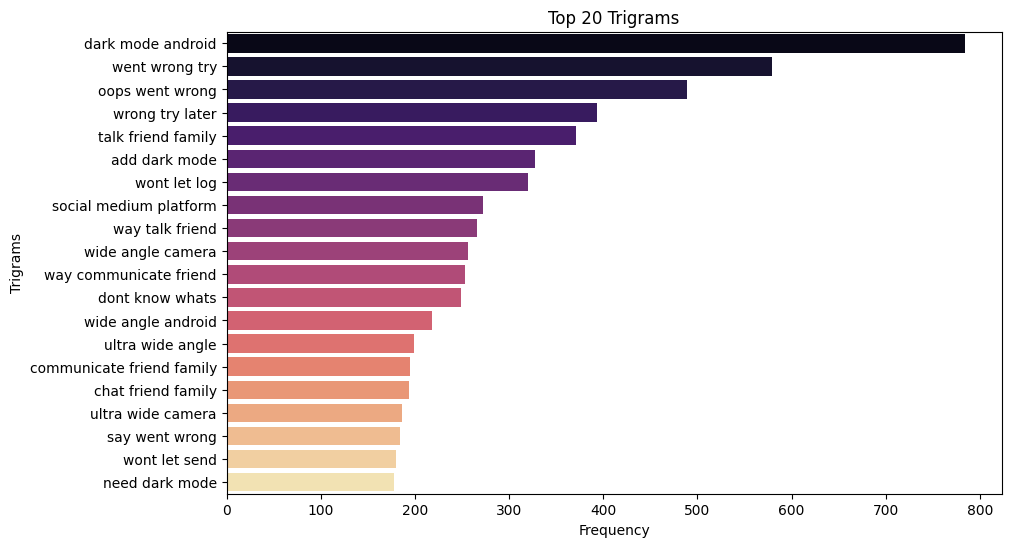

In [28]:
countvec = CountVectorizer(ngram_range=(3,3), stop_words='english')
matrixvec = countvec.fit_transform(data_df['lda_text_strict'])
counts = np.asarray(matrixvec.sum(axis=0)).flatten()
features = countvec.get_feature_names_out()

idx = np.argsort(counts)[::-1][:20]
ttwords = features[idx]
ttcounts = counts[idx]

plt.figure(figsize=(10,6))
sns.barplot(x=ttcounts, y=ttwords, hue=ttwords, palette='magma', legend=False)
plt.title("Top 20 Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.show()

In [29]:
def clean_text_embeddings(text):
    text = str(text).lower()
    text = re.sub(r'[^\x00-\x7F]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', '', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [30]:
data_df['cleaned_text_embeddings'] = data_df['cleaned_content_translated'].apply(clean_text_embeddings)
data_df['cleaned_text_embeddings'].head(10)

0                                                 best
1                                            reputable
2                                                angel
3                           i think it is the best app
4    love how this app work i use from three years ...
5                           wow this app was very good
6                                             very bad
7                                                 love
8                                                 good
9    waseem khan mewati video pigeon kill slingshot...
Name: cleaned_text_embeddings, dtype: str

In [31]:
data_df = data_df.drop_duplicates(subset=['cleaned_text_embeddings'])

## Sentiment analysis

### Vader

In [32]:
analyzer = SentimentIntensityAnalyzer()

In [33]:
rawtext = "you are a very bad person"
analyzer.polarity_scores(rawtext)

{'neg': 0.431, 'neu': 0.569, 'pos': 0.0, 'compound': -0.5849}

In [34]:
def vader_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [35]:
data_df['vader_sentiment'] = (data_df['cleaned_text_embeddings'].apply(vader_sentiment))

In [36]:
def scoretosentiment(score):
    if score >= 4:
        return 'Positive'
    elif score <= 2:
        return 'Negative'
    else:
        return 'Neutral'

In [37]:
data_df['score_sentiment'] = data_df['score'].apply(scoretosentiment)

In [38]:
print(accuracy_score(data_df['score_sentiment'], data_df['vader_sentiment']))

0.5741573323033347


In [39]:
print(confusion_matrix(data_df['score_sentiment'], data_df['vader_sentiment']))

[[40699 15962 27185]
 [ 6478  3183 12429]
 [ 6655 13979 67605]]


In [40]:
print(classification_report(data_df['score_sentiment'], data_df['vader_sentiment']))

              precision    recall  f1-score   support

    Negative       0.76      0.49      0.59     83846
     Neutral       0.10      0.14      0.12     22090
    Positive       0.63      0.77      0.69     88239

    accuracy                           0.57    194175
   macro avg       0.49      0.47      0.47    194175
weighted avg       0.62      0.57      0.58    194175



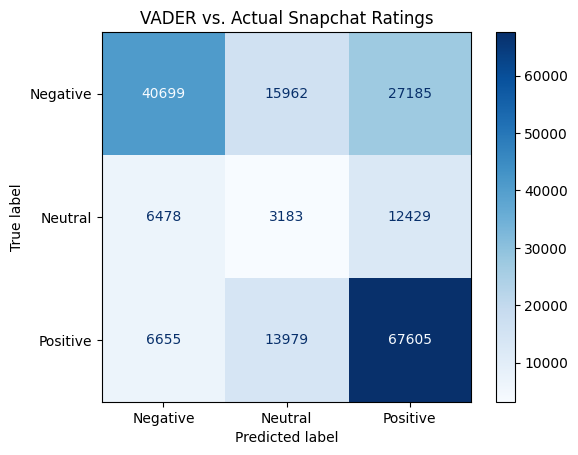

In [41]:
ConfusionMatrixDisplay.from_predictions(
    data_df['score_sentiment'], 
    data_df['vader_sentiment'], 
    display_labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues'
)

plt.title('VADER vs. Actual Snapchat Ratings')
plt.show()

### Roberta

In [ ]:
roberta_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

In [ ]:
def roberta_sentiment(text):
    result = roberta_pipeline(text,truncation=True,max_length=512)[0]

    label = result['label']

    if label == 'LABEL_0':
        return 'Negative'

    elif label == 'LABEL_1':
        return 'Neutral'

    else:
        return 'Positive'

In [ ]:
data_df['roberta_sentiment'] = (data_df['cleaned_text_embeddings'].apply(roberta_sentiment))

In [ ]:
print(accuracy_score(data_df['score_sentiment'], data_df['roberta_sentiment']))

In [ ]:
print(classification_report(data_df['score_sentiment'], data_df['roberta_sentiment']))

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    data_df['score_sentiment'], 
    data_df['roberta_sentiment'], 
    display_labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues'
)

plt.title('Roberta vs. Actual Snapchat Ratings')
plt.show()

### Logistic regression

In [48]:
tfidf = TfidfVectorizer(max_features=5000,min_df=5,max_df=0.90)

In [49]:
tfidf_matrix = tfidf.fit_transform(data_df['lda_text'])

In [50]:
x = tfidf_matrix
y = data_df['score_sentiment']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
lrmodel = LogisticRegression(max_iter=1000)

In [53]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga']
}

In [54]:
grid_search = GridSearchCV(estimator=lrmodel, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

In [55]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [56]:
print(grid_search.best_params_)

{'C': 1, 'solver': 'saga'}


In [57]:
best_model = grid_search.best_estimator_

In [58]:
y_pred = best_model.predict(x_test)

In [59]:
print(accuracy_score(y_test, y_pred))

0.761297798377752


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.75      0.85      0.79     16742
     Neutral       0.36      0.05      0.09      4379
    Positive       0.79      0.85      0.82     17714

    accuracy                           0.76     38835
   macro avg       0.63      0.59      0.57     38835
weighted avg       0.72      0.76      0.73     38835



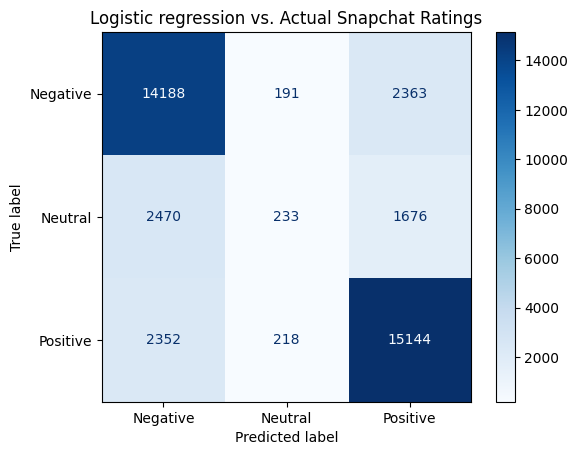

In [61]:
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['Negative', 'Neutral', 'Positive'],
    cmap='Blues'
)

plt.title('Logistic regression vs. Actual Snapchat Ratings')
plt.show()

Among all the models roberta is the one which performed the best. Even though the accuracy for the logistic regression model is high but model is not intelligent enough to say whether the sentiment was positive, negative or neutral. For example there might be a score of 3 but then the customer might be really unhappy. Logistic regression wont be able to predict that only models like roberta will be able to do that.

## Topic modelling

### LDA

In [62]:
vectorizer = CountVectorizer(max_df=0.90,min_df=5,ngram_range=(1,2))
vectorizer_matrix = vectorizer.fit_transform(data_df['lda_text_strict'])

In [ ]:
def ldamodelscoring(kvalues, data_df, vectorizer_matrix, vectorizer):
    tokenized_texts = [text.split() for text in data_df['lda_text_strict']]
    dictionary = Dictionary(tokenized_texts)
    words = vectorizer.get_feature_names_out()
    perplexityscores = []
    coherencescores = []
    
    print(f"{'K-Value':<10} | {'Perplexity':<15} | {'Coherence Score':<15}")
    print("-" * 45)

    for k in kvalues: # Changed 'i' to 'k' for clarity
        lda_model = LatentDirichletAllocation(n_components=k, random_state=42, learning_method='batch')
        lda_model.fit(vectorizer_matrix)
        
        # Perplexity
        perplexity = lda_model.perplexity(vectorizer_matrix)
        perplexityscores.append(perplexity)
        
        # Extract Topics
        topics = []
        for topic in lda_model.components_:
            # FIXED: Changed 'i' to 'idx' to avoid conflict with the outer loop
            topic_words = [words[idx] for idx in topic.argsort()[-10:]]
            topics.append(topic_words)
        
        # Coherence
        coherence_model = CoherenceModel(topics=topics, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
        coherence_score = coherence_model.get_coherence()
        coherencescores.append(coherence_score)
        
        # Print live update
        print(f"{k:<10} | {perplexity:<15.2f} | {coherence_score:<15.4f}")

    # Build DataFrame
    results_df = pd.DataFrame({
        'K-Value': kvalues,
        'Perplexity': perplexityscores,
        'Coherence Score': coherencescores
    })

    # Plotting
    plt.figure(figsize=(10, 6)) # Explicitly create figure
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    ax1.set_xlabel('Number of Topics (k)')
    ax1.set_ylabel('Coherence Score (c_v)', color='tab:blue')
    ax1.plot(kvalues, coherencescores, marker='o', color='tab:blue', label='Coherence')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Perplexity', color='tab:red')
    ax2.plot(kvalues, perplexityscores, marker='x', linestyle='--', color='tab:red', label='Perplexity')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title('LDA Topic Optimization: Coherence vs Perplexity')
    fig.tight_layout()
    plt.show()

    return results_df

K-Value    | Perplexity      | Coherence Score
---------------------------------------------
2          | 5472.50         | 0.5400         
3          | 5226.59         | 0.5715         
4          | 5192.93         | 0.5775         
5          | 5071.74         | 0.5737         
6          | 5065.90         | 0.5842         
7          | 5122.47         | 0.5802         
8          | 5010.01         | 0.5670         
9          | 5030.45         | 0.5668         
10         | 5060.76         | 0.5581         
11         | 5069.83         | 0.5517         
12         | 5087.42         | 0.5643         
13         | 5047.84         | 0.5699         
14         | 5093.70         | 0.5606         
15         | 5010.77         | 0.5827         
16         | 4979.24         | 0.5925         
17         | 4950.67         | 0.5929         
18         | 4931.07         | 0.5948         
19         | 4953.80         | 0.5970         
20         | 4989.45         | 0.5969         


<Figure size 1000x600 with 0 Axes>

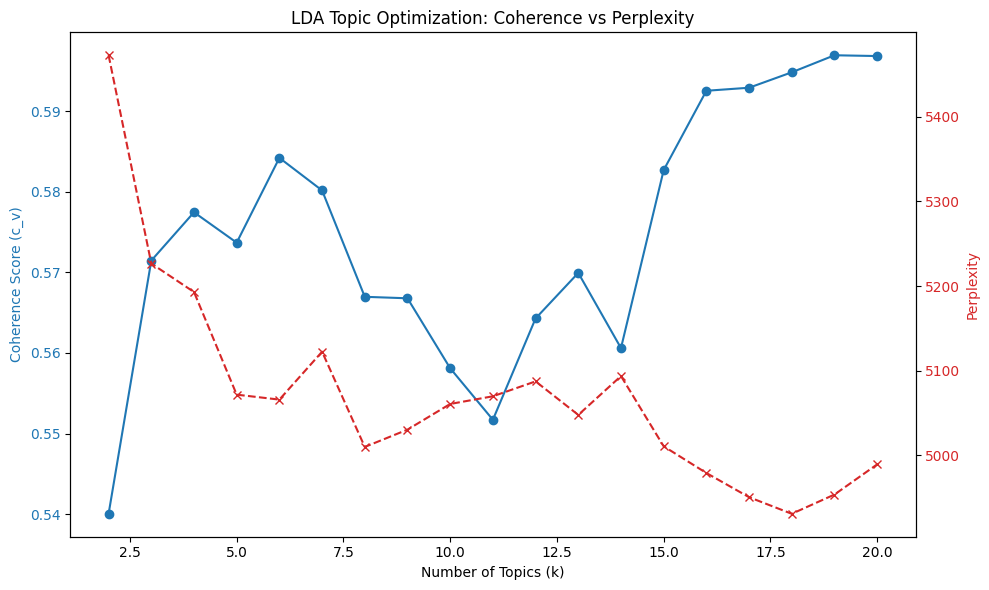

In [64]:
kvalues = list(range(2,21))
result = ldamodelscoring(kvalues, data_df, vectorizer_matrix, vectorizer)

In [65]:
lda_model = LatentDirichletAllocation(n_components=19, random_state=42, learning_method='batch')
lda_model.fit_transform(vectorizer_matrix)

array([[0.05263158, 0.05263158, 0.05263158, ..., 0.05263158, 0.05263158,
        0.05263158],
       [0.05263158, 0.05263158, 0.05263158, ..., 0.05263158, 0.05263158,
        0.05263158],
       [0.02631579, 0.02631579, 0.02631579, ..., 0.02631579, 0.02631579,
        0.02631579],
       ...,
       [0.00309598, 0.00309598, 0.00309598, ..., 0.00309598, 0.00309598,
        0.00309598],
       [0.00309598, 0.00309598, 0.00309598, ..., 0.8789087 , 0.00309598,
        0.00309598],
       [0.00657895, 0.00657895, 0.00657895, ..., 0.88157894, 0.00657895,
        0.00657895]], shape=(194175, 19))

In [66]:
n_top_words = 20
words = vectorizer.get_feature_names_out()

print(f"--- Top {n_top_words} Words per Topic ---")
print(f"Total Topics: {len(lda_model.components_)}\n")

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-n_top_words - 1:-1]
    top_words = [words[i] for i in top_indices]
    print(f"TOPIC #{topic_idx + 1}:")
    print(", ".join(top_words))
    print("=" * 60)

--- Top 20 Words per Topic ---
Total Topics: 19

TOPIC #1:
photo, look, ever, worst, camera, bitmojis, old, front, bitmoji, face, bad, change, ugly, zoomed, seen, front camera, used, bring, internet, give
TOPIC #2:
android, mode, dark, dark mode, user, feature, iphone, phone, pay, dont, android user, cant, apple, free, pin, money, update, samsung, need, android phone
TOPIC #3:
sometimes, video, slow, social, medium, game, social medium, play, send, always, easy, apps, bad, fun, doesnt, glitch, come, load, way, lag
TOPIC #4:
video, feature, add, change, need, music, better, story, sound, option, could, record, post, instagram, quality, second, username, user, picture, wish
TOPIC #5:
send, option, bug, chat, working, issue, cant, soon, possible, able, plz, solve, song, save, help, soon possible, showing, click, request, filter
TOPIC #6:
send, screen, message, sending, black, text, say, picture, someone, sent, something, cant, wont, getting, turn, worse, try, show, story, send message
TOP

### Berttopics

In [67]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [68]:
def bertopic_scoring(min_cluster_sizes, data_df):
    """
    Optimized BERTopic scoring that pre-calculates embeddings 
    to prevent redundant deep learning computations.
    """
    # 1. PRE-CALCULATE EMBEDDINGS (THE SLOW PART - DONE ONCE)
    print("Step 1: Generating Sentence Embeddings...")
    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # We use the raw/cleaned text for embedding and the lda_text for coherence
    documents = data_df['cleaned_text_embeddings'].astype(str).tolist()
    embeddings = embedding_model.encode(documents, show_progress_bar=True)
    
    # Pre-tokenize documents for the Coherence Model
    tokenized_texts = [doc.split() for doc in documents]
    dictionary = Dictionary(tokenized_texts)

    coherence_scores = []
    topic_counts = []

    print(f"\n{'Min Cluster':<15} | {'Topics':<10} | {'Coherence':<15}")
    print("-" * 50)

    # 2. OPTIMIZATION LOOP
    for cluster_size in min_cluster_sizes:
        # Define UMAP (Reduces dimensionality)
        umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, 
                          metric='cosine', random_state=42)

        # Define HDBSCAN (Clusters the points)
        hdbscan_model = HDBSCAN(min_cluster_size=cluster_size, metric='euclidean', 
                                cluster_selection_method='eom', prediction_data=True)

        # Initialize BERTopic - setting embedding_model=None is CRITICAL here
        topic_model = BERTopic(
            embedding_model=None, 
            umap_model=umap_model, 
            hdbscan_model=hdbscan_model, 
            verbose=False
        )

        # Fit model using pre-calculated embeddings
        try:
            topics, _ = topic_model.fit_transform(documents, embeddings=embeddings)
            
            # Get valid topics (excluding outlier topic -1)
            topic_info = topic_model.get_topic_info()
            valid_topics = topic_info[topic_info.Topic != -1]
            
            num_topics = len(valid_topics)
            topic_counts.append(num_topics)

            # Extract topic words for coherence calculation
            topic_words = []
            for topic_num in valid_topics.Topic:
                words = topic_model.get_topic(topic_num)
                if words:
                    # BERTopic returns (word, score) tuples; we only need the word
                    topic_words.append([word[0] for word in words[:10]])

            # 3. CALCULATE COHERENCE
            if num_topics > 1: # Coherence requires at least 2 topics
                coherence_model = CoherenceModel(
                    topics=topic_words, 
                    texts=tokenized_texts, 
                    dictionary=dictionary, 
                    coherence='c_v'
                )
                score = coherence_model.get_coherence()
            else:
                score = 0
                
        except Exception as e:
            print(f"Error at cluster size {cluster_size}: {e}")
            score = 0
            num_topics = 0

        coherence_scores.append(score)
        print(f"{cluster_size:<15} | {num_topics:<10} | {score:<15.4f}")

    # 4. TABULATE AND PLOT RESULTS
    results_df = pd.DataFrame({
        'Min Cluster Size': min_cluster_sizes,
        'Topic Count': topic_counts,
        'Coherence Score': coherence_scores
    })

    plt.figure(figsize=(10, 6))
    plt.plot(min_cluster_sizes, coherence_scores, marker='o', linestyle='-', color='teal')
    plt.xlabel('Min Cluster Size (HDBSCAN)')
    plt.ylabel('Coherence Score (c_v)')
    plt.title('BERTopic Parameter Optimization')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    return results_df

In [69]:
sample_df = data_df.sample(10000,random_state=42)

Step 1: Generating Sentence Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]


Min Cluster     | Topics     | Coherence      
--------------------------------------------------
2               | 1027       | 0.3603         
3               | 520        | 0.3507         
4               | 318        | 0.3783         
5               | 238        | 0.4105         
6               | 202        | 0.4331         
7               | 178        | 0.4432         
8               | 158        | 0.4688         
9               | 138        | 0.4827         
10              | 129        | 0.4844         
11              | 112        | 0.5064         
12              | 107        | 0.5145         
13              | 98         | 0.5372         
14              | 89         | 0.5475         
15              | 90         | 0.5492         
16              | 86         | 0.5532         
17              | 79         | 0.5611         
18              | 75         | 0.5682         
19              | 73         | 0.5758         


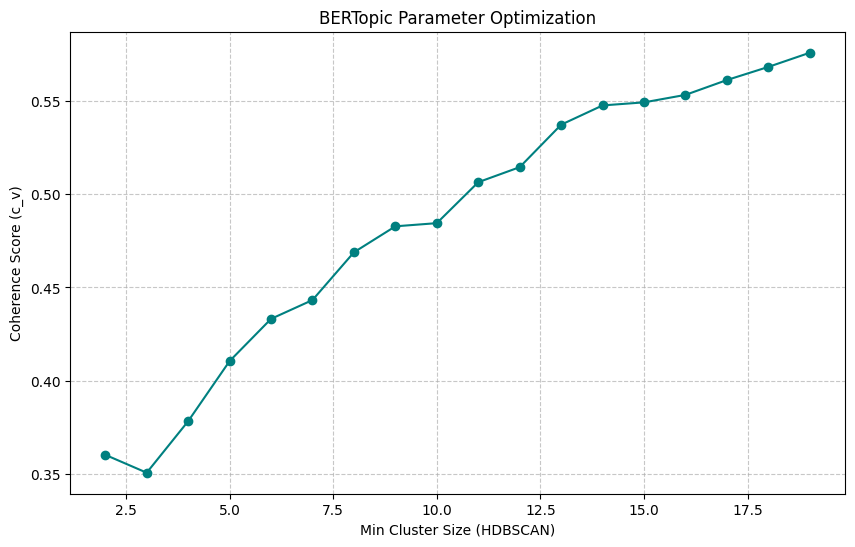

In [70]:
results = bertopic_scoring( min_cluster_sizes=list(range(2,20)),data_df=sample_df)

In [71]:
umap_model = UMAP(n_neighbors=30, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=500, metric='euclidean',  cluster_selection_method='eom', prediction_data=True)
berttopic_model = BERTopic(embedding_model=None, umap_model=umap_model,  hdbscan_model=hdbscan_model, verbose=False)

In [72]:
documents = data_df['cleaned_text_embeddings'].astype(str).tolist()
embeddings = embedding_model.encode(documents, show_progress_bar=True)

Batches:   0%|          | 0/6068 [00:00<?, ?it/s]

In [73]:
berttopic_model.fit_transform(documents, embeddings=embeddings)

([2,
  2,
  19,
  5,
  14,
  5,
  2,
  2,
  2,
  1,
  11,
  24,
  1,
  -1,
  -1,
  24,
  2,
  -1,
  -1,
  5,
  0,
  0,
  0,
  5,
  1,
  41,
  5,
  -1,
  2,
  28,
  2,
  2,
  5,
  -1,
  19,
  2,
  1,
  1,
  5,
  1,
  0,
  5,
  5,
  0,
  1,
  -1,
  -1,
  1,
  14,
  25,
  -1,
  2,
  2,
  2,
  2,
  0,
  -1,
  26,
  2,
  15,
  -1,
  4,
  3,
  3,
  -1,
  -1,
  2,
  2,
  27,
  13,
  2,
  8,
  2,
  2,
  2,
  2,
  5,
  -1,
  2,
  5,
  -1,
  1,
  5,
  0,
  0,
  -1,
  5,
  5,
  -1,
  5,
  2,
  -1,
  0,
  -1,
  47,
  1,
  2,
  0,
  34,
  -1,
  5,
  5,
  5,
  0,
  -1,
  18,
  49,
  17,
  -1,
  4,
  1,
  19,
  1,
  6,
  2,
  2,
  16,
  1,
  2,
  1,
  31,
  14,
  0,
  5,
  26,
  25,
  -1,
  5,
  1,
  -1,
  5,
  1,
  -1,
  14,
  2,
  9,
  5,
  -1,
  16,
  1,
  3,
  1,
  2,
  -1,
  0,
  2,
  0,
  20,
  26,
  -1,
  17,
  -1,
  4,
  5,
  1,
  1,
  2,
  1,
  -1,
  2,
  27,
  2,
  24,
  30,
  2,
  5,
  -1,
  2,
  23,
  5,
  2,
  0,
  2,
  9,
  -1,
  20,
  2,
  9,
  -1,
  -1,
  5,
  14,
  -1,
  -1,
  1,
  2

In [81]:
berttopic_model.reduce_topics(

    documents,

    nr_topics=20
)

In [85]:
topic_info = berttopic_model.get_topic_info()

topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,60184,-1_the_and_it_to,"[the, and, it, to, is, app, my, this, but, its]",[well i like snapchat so much its a very fun a...
1,0,29227,0_snapchat_and_my_to,"[snapchat, and, my, to, it, is, the, snap, app...",[ive had snapchat for years and it just now wa...
2,1,27483,1_app_this_it_and,"[app, this, it, and, is, the, very, to, good, ...","[good app like this app, this is the best app ..."
3,2,18110,2_good_very_hai_nice,"[good, very, hai, nice, its, so, it, you, love...","[its nice good, so so good i like this is very..."
4,3,9849,3_account_my_it_to,"[account, my, it, to, log, and, in, me, passwo...",[wouldnt send messages so when i logged out it...
5,4,9059,4_camera_the_video_it,"[camera, the, video, it, and, to, my, videos, ...",[on my samsung note the camera is not as good ...
6,5,5886,5_notifications_messages_the_notification,"[notifications, messages, the, notification, t...",[i dont get notifications when i receive snaps...
7,6,4488,6_dark_mode_android_the,"[dark, mode, android, the, for, to, have, but,...",[all i want is to get dark mode on android i k...
8,7,4444,7_memories_pay_storage_for,"[memories, pay, storage, for, to, years, have,...",[ive had snapchat for so many years and all my...
9,8,4373,8_ai_the_to_remove,"[ai, the, to, remove, it, of, top, rid, you, and]",[absolutely hate the my ai pinned on top of my...


In [86]:
tokenized_texts = [doc.split() for doc in documents]
dictionary = Dictionary(tokenized_texts)
topic_info = berttopic_model.get_topic_info()
valid_topics = topic_info[topic_info.Topic != -1]
topic_words = []
for topic_num in valid_topics.Topic:
    words = berttopic_model.get_topic(topic_num)
    if words:
        topic_words.append([word[0] for word in words[:10]])

In [87]:
coherence_model = CoherenceModel(topics=topic_words,texts=tokenized_texts,dictionary=dictionary,coherence='c_v')
score = coherence_model.get_coherence()
print(score)

0.6468130390513809


In [83]:
berttopic_model.visualize_barchart(top_n_topics=10, n_words=30)
berttopic_model.visualize_topics()

In [84]:
representative_docs = berttopic_model.get_representative_docs(0)

print("Representative reviews for this topic:")
for i, doc in enumerate(representative_docs):
    print(f"{i+1}. {doc[:200]}...")

Representative reviews for this topic:
1. ive had snapchat for years and it just now wants to give me problems i dont know whats going on or if they are working on the app or im just the unlucky one to get stuck ive tried to log in it brings ...
2. snapchat is very fun because you can have friends and you wont always have to be lonely so if you never have friends you can just add them but also you need to choose your friends of very wisely and m...
3. i dont know if its my phone that is causing the problem on snapchat or its just the app when i updated snapchat everything was fine at first until snapchat started to freeze and i had to exit the app ...


Even though the Bert topic have given better coherence score. The LDA seems to be more fit for this topic modelling as it has given clear topics of issues related and other features. So we will be using the LDA topic modelling instead of bert topic with n value as 19.